In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
# Example book sales dataset
data = {
    "book_id": [1, 2, 3, 4, 5],
    "title": [
        "Deep Learning with Python",
        "LLMs Explained",
        "AI for Everyone",
        "Mastering Transformers",
        "Generative Models"
    ],
    "author": [
        "Francois Chollet", "Jane AI", "Sam Reader", "Alex NLP", "Lee Deep"
    ],
    "platform": [
        "Amazon", "Barnes & Noble", "Apple Books", "Amazon", "Amazon"
    ],
    "format": [
        "ebook", "hardcover", "paperback", "ebook", "hardcover"
    ],
    "date_sold": [
        "2025-01-10", "2025-01-15", "2025-01-15", "2025-02-01", "2025-02-05"
    ],
    "units_sold": [500, 120, 320, 450, 210],
    "sale_price_usd": [29.99, 45.00, 39.99, 24.99, 49.99],
    "gross_sales_usd": [14995, 5400, 12796, 11245, 10497],
    "publisher_revenue_usd": [10000, 3500, 9000, 8000, 7500],
    "production_cost_usd": [1500, 1800, 2000, 1200, 1700],
    "ads_spent_usd": [2000, 1200, 1500, 1800, 1300]
}

df = pd.DataFrame(data)
df["date_sold"] = pd.to_datetime(df["date_sold"])


In [3]:
# Calculate net profit
df["net_profit_usd"] = df["publisher_revenue_usd"] - (df["production_cost_usd"] + df["ads_spent_usd"])

# Calculate profit margin
df["profit_margin_pct"] = (df["net_profit_usd"] / df["gross_sales_usd"]) * 100

# Show dataset
df


,book_id,title,author,platform,format,date_sold,units_sold,sale_price_usd,gross_sales_usd,publisher_revenue_usd,production_cost_usd,ads_spent_usd,net_profit_usd,profit_margin_pct
0,1,Deep Learning with Python,Francois Chollet,Amazon,ebook,2025-01-10,500,29.99,14995,10000,1500,2000,6500,43.347783
1,2,LLMs Explained,Jane AI,Barnes & Noble,hardcover,2025-01-15,120,45.00,5400,3500,1800,1200,500,9.259259
2,3,AI for Everyone,Sam Reader,Apple Books,paperback,2025-01-15,320,39.99,12796,9000,2000,1500,5500,42.982182
3,4,Mastering Transformers,Alex NLP,Amazon,ebook,2025-02-01,450,24.99,11245,8000,1200,1800,5000,44.464206
4,5,Generative Models,Lee Deep,Amazon,hardcover,2025-02-05,210,49.99,10497,7500,1700,1300,4500,42.869391


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_14904/2716379386.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M")["units_sold"].sum()


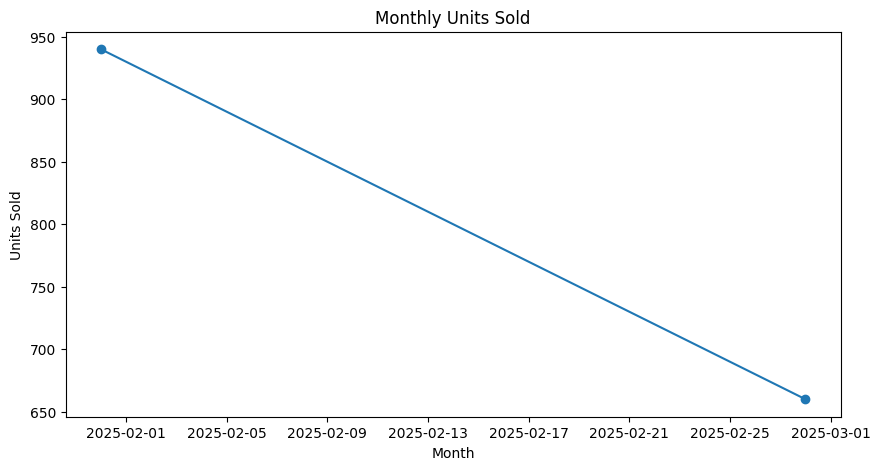

In [4]:
# Daily/Monthly sales trends
df.set_index("date_sold", inplace=True)

monthly_sales = df.resample("M")["units_sold"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()


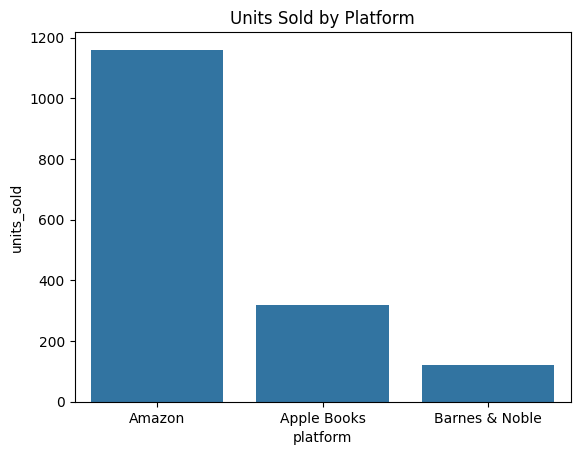

In [5]:
platform_summary = df.groupby("platform").agg({
    "units_sold": "sum",
    "gross_sales_usd": "sum",
    "net_profit_usd": "sum"
}).reset_index()

sns.barplot(data=platform_summary, x="platform", y="units_sold")
plt.title("Units Sold by Platform")
plt.show()


In [6]:
# Top performing format
format_summary = df.groupby("format").agg({
    "units_sold": "sum",
    "gross_sales_usd": "sum",
    "net_profit_usd": "sum"
})

format_summary["ROI_pct"] = (format_summary["net_profit_usd"] / format_summary["gross_sales_usd"]) * 100
format_summary


,units_sold,gross_sales_usd,net_profit_usd,ROI_pct
format,,,,
ebook,950,26240,11500,43.826220
hardcover,330,15897,5000,31.452475
paperback,320,12796,5500,42.982182
